# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

## Setup and load data
Add the project root to the import path, load the TXT dataset, and split into train/test for modeling.

In [68]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data

df = load_illness_data("SCZ", in_notebook=True)

Loading data for illness SCZ at /Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/data/tmpDATA-Leon/donnees_MRI_SCZ_only_variants_clumping_p_thr_0.0001all.txt


In [71]:
df.head(5)
# remove the column with Z score and ID
df = df.drop(columns=["Z_scores_SCZ", "ID"])


In [72]:
# list out the columns of the dataframe, but all of them, not just the first 5, because its many columns and we want to see all of them
print(df.columns.tolist())

['Mean_intensity_3rd-Ventricle_whole-brain', 'Mean_intensity_4th-Ventricle_whole-brain', 'Mean_intensity_Brain-Stem_whole-brain', 'Mean_intensity_CSF_whole-brain', 'Mean_intensity_WM-hypointensities_whole-brain', 'Mean_intensity_Optic-Chiasm_whole-brain', 'Mean_intensity_CC-Posterior_whole-brain', 'Mean_intensity_CC-Mid-Posterior_whole-brain', 'Mean_intensity_CC-Central_whole-brain', 'Mean_intensity_CC-Mid-Anterior_whole-brain', 'Mean_intensity_CC-Anterior_whole-brain', 'Volume_BrainSeg_whole-brain', 'Volume_BrainSegNotVent_whole-brain', 'Volume_BrainSegNotVentSurf_whole-brain', 'Volume_SubCortGray_whole-brain', 'Volume_TotalGray_whole-brain', 'Volume_SupraTentorial_whole-brain', 'Volume_SupraTentorialNotVent_whole-brain', 'Volume_EstimatedTotalIntraCranial_whole-brain', 'Volume_VentricleChoroid_whole-brain', 'Volume_3rd-Ventricle_whole-brain', 'Volume_4th-Ventricle_whole-brain', 'Volume_Brain-Stem_whole-brain', 'Volume_CSF_whole-brain', 'Volume_WM-hypointensities_whole-brain', 'Volume

In [73]:
# parse the columns into the ones that and in _right and _left and the remaining ones
right_columns = [col for col in df.columns if col.endswith('_right')]
left_columns = [col for col in df.columns if col.endswith('_left')]
other_columns = [col for col in df.columns if not (col.endswith('_right') or col.endswith('_left'))]

In [74]:
len(right_columns), len(left_columns), len(other_columns)

(486, 486, 38)

In [75]:
other_columns

['Mean_intensity_3rd-Ventricle_whole-brain',
 'Mean_intensity_4th-Ventricle_whole-brain',
 'Mean_intensity_Brain-Stem_whole-brain',
 'Mean_intensity_CSF_whole-brain',
 'Mean_intensity_WM-hypointensities_whole-brain',
 'Mean_intensity_Optic-Chiasm_whole-brain',
 'Mean_intensity_CC-Posterior_whole-brain',
 'Mean_intensity_CC-Mid-Posterior_whole-brain',
 'Mean_intensity_CC-Central_whole-brain',
 'Mean_intensity_CC-Mid-Anterior_whole-brain',
 'Mean_intensity_CC-Anterior_whole-brain',
 'Volume_BrainSeg_whole-brain',
 'Volume_BrainSegNotVent_whole-brain',
 'Volume_BrainSegNotVentSurf_whole-brain',
 'Volume_SubCortGray_whole-brain',
 'Volume_TotalGray_whole-brain',
 'Volume_SupraTentorial_whole-brain',
 'Volume_SupraTentorialNotVent_whole-brain',
 'Volume_EstimatedTotalIntraCranial_whole-brain',
 'Volume_VentricleChoroid_whole-brain',
 'Volume_3rd-Ventricle_whole-brain',
 'Volume_4th-Ventricle_whole-brain',
 'Volume_Brain-Stem_whole-brain',
 'Volume_CSF_whole-brain',
 'Volume_WM-hypointensiti

In [76]:
# print all right columns
print(right_columns)

['Mean_intensity_Lateral-Ventricle_right', 'Mean_intensity_Inf-Lat-Vent_right', 'Mean_intensity_Cerebellum-White-Matter_right', 'Mean_intensity_Cerebellum-Cortex_right', 'Mean_intensity_Thalamus-Proper_right', 'Mean_intensity_Caudate_right', 'Mean_intensity_Putamen_right', 'Mean_intensity_Pallidum_right', 'Mean_intensity_Hippocampus_right', 'Mean_intensity_Amygdala_right', 'Mean_intensity_Accumbens-area_right', 'Mean_intensity_VentralDC_right', 'Mean_intensity_vessel_right', 'Mean_intensity_choroid-plexus_right', 'Volume_Cortex_right', 'Volume_CerebralWhiteMatter_right', 'Volume_Lateral-Ventricle_right', 'Volume_Inf-Lat-Vent_right', 'Volume_Cerebellum-White-Matter_right', 'Volume_Cerebellum-Cortex_right', 'Volume_Thalamus-Proper_right', 'Volume_Caudate_right', 'Volume_Putamen_right', 'Volume_Pallidum_right', 'Volume_Hippocampus_right', 'Volume_Amygdala_right', 'Volume_Accumbens-area_right', 'Volume_VentralDC_right', 'Volume_vessel_right', 'Volume_choroid-plexus_right', 'Number_HolesBef

In [77]:
# the names of the features are ["Mean_intesity", "Volume", "Area", "Mean_thickness", "Grey-white_contrast"]_<some_location>_right
# group the features by the starting part of the name, i.e. Mean_intesity, Volume, Area, Mean_thickness, Grey-white_contrast
feature_groups = {}
for col in other_columns:
    feature_name = col.split('_')[0]  # Get the part before the first underscore
    # if feature name is mean, then we need to get the part before the second underscore, because mean_intensity is one feature name
    if feature_name == "Mean":
        feature_name = '_'.join(col.split('_')[:2])  # Get the part before the second underscore
    if feature_name not in feature_groups:
        feature_groups[feature_name] = []
    feature_groups[feature_name].append(col)

In [78]:
# print length of each feature group
for feature_name, cols in feature_groups.items():
    print(f"{feature_name}: {len(cols)} columns")

Mean_intensity: 11 columns
Volume: 25 columns
Volume-ratio: 2 columns


In [59]:
feature_groups["Number"]

KeyError: 'Number'

In [79]:
# the names of the features are ["Mean_intesity", "Volume", "Area", "Mean_thickness", "Grey-white_contrast"]_<some_location>_right
# group the features by the location, so we have a dictionary where the keys are the locations and the values are lists of features that belong to that location
from collections import defaultdict
location_groups = defaultdict(list)
for col in other_columns:
    # the location is the part of the name that comes after the feature name, so we need to split the name by underscores and get the part that comes after the feature name
    feature_name = col.split('_')[0]  # Get the part before the first underscore
    if feature_name == "Mean":
        feature_name = '_'.join(col.split('_')[:2])  # Get the part before the second underscor
    location = col.split('_')[-2]  # Get the part before the last underscore
    location_groups[location].append(col)
# print length of each location group
for location, cols in location_groups.items():
    print(f"{location}: {len(cols)} columns")

# remove the location HolesBeforeFixing from the location groups, because it is not a real location, but an artifact of the preprocessing
#del location_groups["HolesBeforeFixing"]

#del location_groups["Z"]
#del location_groups["ID"]


3rd-Ventricle: 2 columns
4th-Ventricle: 2 columns
Brain-Stem: 2 columns
CSF: 2 columns
WM-hypointensities: 2 columns
Optic-Chiasm: 2 columns
CC-Posterior: 2 columns
CC-Mid-Posterior: 2 columns
CC-Central: 2 columns
CC-Mid-Anterior: 2 columns
CC-Anterior: 2 columns
BrainSeg: 1 columns
BrainSegNotVent: 1 columns
BrainSegNotVentSurf: 1 columns
SubCortGray: 1 columns
TotalGray: 1 columns
SupraTentorial: 1 columns
SupraTentorialNotVent: 1 columns
EstimatedTotalIntraCranial: 1 columns
VentricleChoroid: 1 columns
BrainSegVol-to-eTIV: 1 columns
MaskVol-to-eTIV: 1 columns
Medulla: 1 columns
Pons: 1 columns
SCP: 1 columns
Midbrain: 1 columns
Whole-brainstem: 1 columns


In [80]:
location_groups["whole-brain"]

[]

In [81]:
# group location groups by number of features, so we have a dictionary where the keys are the number of features and the values are lists of locations that have that number of features
features_per_location = defaultdict(list)
for location, cols in location_groups.items():
    features_per_location[len(cols)].append(location)
# print length of each features per location group
total = 0
for num_features, locations in features_per_location.items():
    print(f"{num_features} features: {len(locations)} locations")
    total += len(locations)*num_features
print(f"Total features: {total}")

2 features: 11 locations
1 features: 16 locations
0 features: 1 locations
Total features: 38


In [83]:
# prepare 5-dimensional array of [Mean_intensity, Volume, Area, Mean_thickness, Grey-white_contrast] for each location, so we have an array of shape (num_locations, num_features_per_location, num_samples)
# assign the values to the array, so that we have the values for each location and each feature in the correct place
# if location groups have different number of features, we need to pad the array with zeros, so that we have the same number of features for each location
import numpy as np
num_locations = len(location_groups)
max_features_per_location = max(len(cols) for cols in location_groups.values())
data_array = np.zeros((num_locations, 6))
location_to_index = {location: idx for idx, location in enumerate(location_groups.keys())}
feature_to_index = {"Mean_intensity": 0, "Volume": 1, "Area": 2, "Mean_thickness": 3, "Grey-white_contrast": 4, "Volume-ratio":5}
for location, cols in location_groups.items():
    location_idx = location_to_index[location]
    for feature_idx, col in enumerate(cols):
        values = df[col].values
        for value in values:
            feature_name = col.split('_')[0]  # Get the part before the first underscore
            if feature_name == "Mean" or feature_name == "Grey-white":
                feature_name = '_'.join(col.split('_')[:2])  # Get the part before the second underscore
            feature_idx = feature_to_index[feature_name]
            data_array[location_idx, feature_idx] = value

data_array.shape
    

(28, 6)

In [86]:
# now apply this to the dataframe
# create right, left and other dataframes, where the columns are the right, left and other columns respectively
df_right = df[right_columns]
df_left = df[left_columns]
df_other = df[other_columns]

num_samples = df.shape[0]
data_array = np.zeros((num_samples, num_locations, 6))

# create location_groups
location_to_index = {location: idx for idx, location in enumerate(location_groups.keys())}
feature_to_index = {"Mean_intensity": 0, "Volume": 1, "Area": 2, "Mean_thickness": 3, "Grey-white_contrast": 4, "Volume-ratio": 5}

for location, cols in location_groups.items():
    location_idx = location_to_index[location]
    for feature_idx, col in enumerate(cols):
        feature_name = col.split('_')[0]  # Get the part before the first underscore
        if feature_name == "Mean" or feature_name == "Grey-white":
            feature_name = '_'.join(col.split('_')[:2])  # Get the part before the second underscore
        feature_idx = feature_to_index[feature_name]
        data_array[:, location_idx, feature_idx] = df[col].values

In [87]:
data_array.shape

(3533, 28, 6)

In [94]:
def get_location_groups(columns):
    location_groups = defaultdict(list)
    for col in columns:
        # the location is the part of the name that comes after the feature name, so we need to split the name by underscores and get the part that comes after the feature name
        feature_name = col.split('_')[0]  # Get the part before the first underscore
        if feature_name == "Mean":
            feature_name = '_'.join(col.split('_')[:2])  # Get the part before the second underscor
        location = col.split('_')[-2]  # Get the part before the last underscore
        location_groups[location].append(col)
    # print length of each location group
    for location, cols in location_groups.items():
        print(f"{location}: {len(cols)} columns")

    if "HolesBeforeFixing" in location_groups:
        del location_groups["HolesBeforeFixing"]
    
    return location_groups



def create_graph(df):
    # create right, left and other dataframes, where the columns are the right, left and other columns respectively
    right_columns = [col for col in df.columns if col.endswith('_right')]
    left_columns = [col for col in df.columns if col.endswith('_left')]
    other_columns = [col for col in df.columns if not (col.endswith('_right') or col.endswith('_left'))]


    columns = [right_columns, left_columns, other_columns]
    location_groups = [get_location_groups(column) for column in columns]

    print(location_groups[0].keys())

    num_samples = df.shape[0]
    data_array = np.zeros((num_samples, len(location_groups[0]), 6))
    data_array_left = np.zeros((num_samples, len(location_groups[1]), 6))
    data_array_other = np.zeros((num_samples, len(location_groups[2]), 6))
    # create location_groups
    feature_to_index = {"Mean_intensity": 0, "Volume": 1, "Area": 2, "Mean_thickness": 3, "Grey-white_contrast": 4, "Volume-ratio": 5}

    for i, location_group in enumerate(location_groups):
        location_to_index = {location: idx for idx, location in enumerate(location_group.keys())}
        for location, cols in location_group.items():
            location_idx = location_to_index[location]
            for feature_idx, col in enumerate(cols):
                feature_name = col.split('_')[0]  # Get the part before the first underscore
                if feature_name == "Mean" or feature_name == "Grey-white":
                    feature_name = '_'.join(col.split('_')[:2])  # Get the part before the second underscore
                feature_idx = feature_to_index[feature_name]
                if i == 0:
                    data_array[:, location_idx, feature_idx] = df[col].values
                elif i == 1:
                    data_array_left[:, location_idx, feature_idx] = df[col].values
                else:
                    data_array_other[:, location_idx, feature_idx] = df[col].values

    # concatenate the three arrays along the location axis, so that we have an array of shape (num_samples, num_locations, num_features_per_location)
    data_array = np.concatenate([data_array, data_array_left, data_array_other], axis=1)
    return data_array

In [95]:
graph = create_graph(df)
graph.shape

Lateral-Ventricle: 2 columns
Inf-Lat-Vent: 2 columns
Cerebellum-White-Matter: 2 columns
Cerebellum-Cortex: 2 columns
Thalamus-Proper: 2 columns
Caudate: 2 columns
Putamen: 2 columns
Pallidum: 2 columns
Hippocampus: 2 columns
Amygdala: 2 columns
Accumbens-area: 2 columns
VentralDC: 2 columns
vessel: 2 columns
choroid-plexus: 2 columns
Cortex: 1 columns
CerebralWhiteMatter: 1 columns
HolesBeforeFixing: 1 columns
Lateral-nucleus: 1 columns
Basal-nucleus: 1 columns
Accessory-Basal-nucleus: 1 columns
Anterior-amygdaloid-area-AAA: 1 columns
Central-nucleus: 1 columns
Medial-nucleus: 1 columns
Cortical-nucleus: 1 columns
Corticoamygdaloid-transitio: 1 columns
Paralaminar-nucleus: 1 columns
Whole-amygdala: 1 columns
Hippocampal-tail: 1 columns
subiculum-body: 1 columns
CA1-body: 1 columns
subiculum-head: 1 columns
hippocampal-fissure: 1 columns
presubiculum-head: 1 columns
CA1-head: 1 columns
presubiculum-body: 1 columns
parasubiculum: 1 columns
molecular-layer-HP-head: 1 columns
molecular-lay

(3533, 423, 6)

In [106]:
# create adjancecy matrix based on correlation between features, so that we have a matrix of shape (num_locations, num_locations)
# we can use the data_array to compute the correlation between features, so that we have a
# matrix of shape (num_locations, num_locations) where the value at (i, j) is the correlation between the features of location i and location j
num_locations = graph.shape[1]
adjacency_matrix = np.zeros((num_locations, num_locations))
for i in range(num_locations):
    for j in range(num_locations):
        if i != j:
            # compute correlation between features of location i and location j
            correlation = np.corrcoef(graph[:, i, :].flatten(), graph[:, j, :].flatten())[0, 1]
            adjacency_matrix[i, j] = correlation
        else:
            adjacency_matrix[i, j] = 1.0  # self-correlation is 1   
adjacency_matrix.shape


(423, 423)

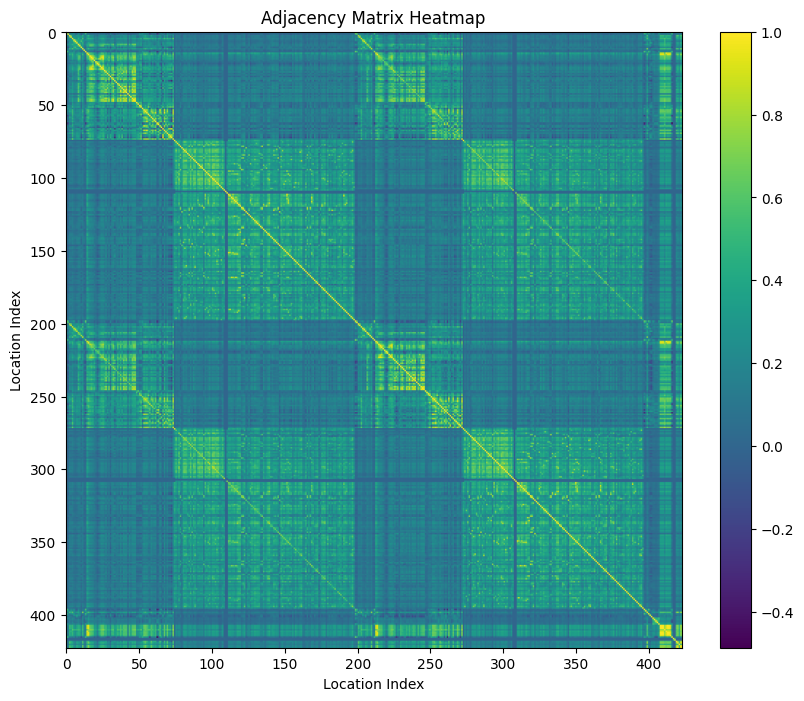

In [116]:
# visualize the adjacency matrix as a heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(adjacency_matrix, cmap='viridis')
plt.colorbar()
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("Location Index")
plt.ylabel("Location Index")
plt.show()

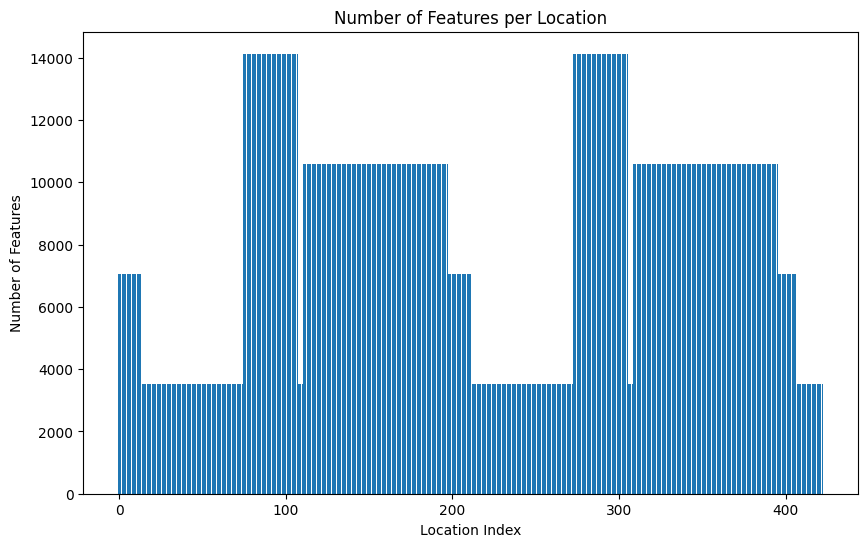

In [118]:
# plot the dimension of the nodes (locations) and the number of features per node, so that we can see how many features we have for each 
# also plot it in 2D so we can see the distribution of features across locations
features_per_location = np.sum(graph != 0, axis=(0, 2))
plt.figure(figsize=(10, 6))
plt.bar(range(len(features_per_location)), features_per_location)
plt.xlabel("Location Index")
plt.ylabel("Number of Features")
plt.title("Number of Features per Location")
plt.show()

In [123]:
# plot the difference in node dimensionality, e.g. the number of non-zero features 
# plot the difference between nodes
num_locations = graph.shape[1]
difference_matrix = np.zeros((num_locations, num_locations))
for i in range(num_locations):
    for j in range(num_locations):
        if i != j:
            # compute difference between features of location i and location j
            difference = np.sum(graph[0, i, :] != 0) - np.sum(graph[0, j, :] != 0)
            difference_matrix[i, j] = difference
        else:
            difference_matrix[i, j] = 0.0  # self-difference is 0
difference_matrix.shape

(423, 423)

In [124]:
difference_matrix

array([[ 0.,  0.,  0., ...,  1.,  1.,  1.],
       [ 0.,  0.,  0., ...,  1.,  1.,  1.],
       [ 0.,  0.,  0., ...,  1.,  1.,  1.],
       ...,
       [-1., -1., -1., ...,  0.,  0.,  0.],
       [-1., -1., -1., ...,  0.,  0.,  0.],
       [-1., -1., -1., ...,  0.,  0.,  0.]], shape=(423, 423))

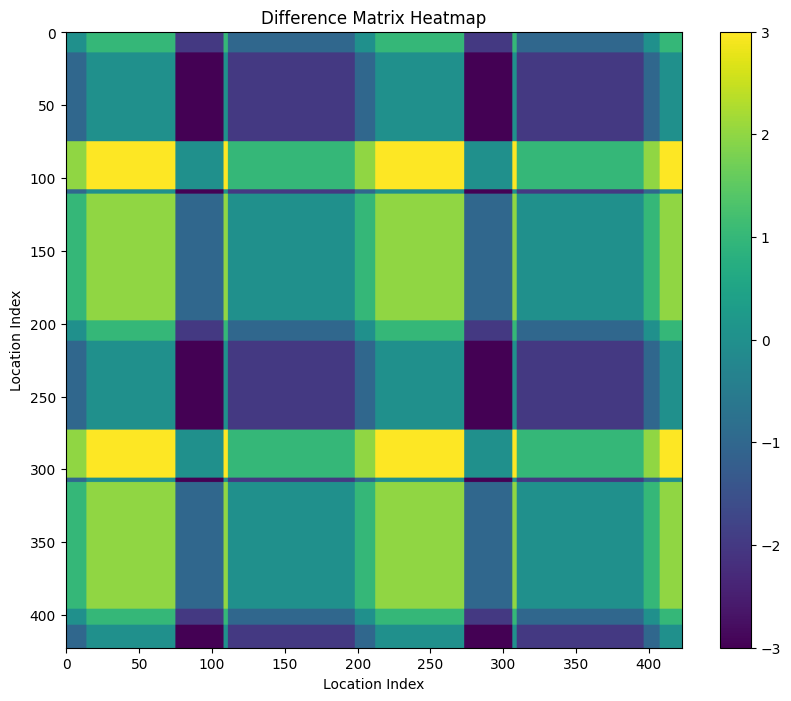

In [125]:
# visualize the adjacency matrix as a heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(difference_matrix, cmap='viridis')
plt.colorbar()
plt.title("Difference Matrix Heatmap")
plt.xlabel("Location Index")
plt.ylabel("Location Index")
plt.show()

In [128]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --- Load target ---
df_with_target = load_illness_data("SCZ", in_notebook=True)
y = df_with_target["Z_scores_SCZ"].values.astype(np.float32)

X = graph.astype(np.float32)  # (3533, 423, 6)
num_nodes = X.shape[1]         # 423
num_node_features = X.shape[2] # 6

# --- Fully connected normalized adjacency (shared across all samples) ---
A = np.ones((num_nodes, num_nodes), dtype=np.float32)
#A = adjacency_matrix.astype(np.float32)  # (N, N)
D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
A_norm = torch.tensor(D_inv_sqrt @ A @ D_inv_sqrt)  # (N, N)

# --- Train / test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train)
X_test_t  = torch.tensor(X_test)
y_train_t = torch.tensor(y_train).unsqueeze(1)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

class AdjacencyGCNLayer(nn.Module):
    "learn the adjacency matrix as a parameter, and use it in the GCN layer"
    def __init__(self, in_f, out_f, num_nodes):
        super().__init__()
        self.W = nn.Linear(in_f, out_f, bias=False)
        self.A = nn.Parameter(torch.ones((num_nodes, num_nodes), dtype=torch.float32))

# --- GCN layer: A_norm @ X @ W  +  ReLU ---
class GCNLayer(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.W = nn.Linear(in_f, out_f, bias=False)

    def forward(self, x, A):
        # x: (B, N, F),  A: (N, N)
        return F.relu(self.W(torch.matmul(A, x)))  # (B, N, out_f)

class SimpleGCN(nn.Module):
    def __init__(self, in_f, hidden):
        super().__init__()
        self.adjacency = nn.Parameter(torch.ones((num_nodes, num_nodes), dtype=torch.float32))  # learnable adjacency
        self.linear = nn.Linear(in_f, hidden)
        self.gcn1 = GCNLayer(hidden, hidden)
        self.gcn2 = GCNLayer(hidden, hidden)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.linear(x)    # (B, N, H)
        x = self.gcn1(x, self.adjacency)   # (B, N, H)
        x = self.gcn2(x, self.adjacency)   # (B, N, H)
        #x = self.gcn3(x, self.adjacency)   # (B, N, H)
        x = x.mean(dim=1)     # (B, H)  — mean pooling over nodes
        return self.fc(x)     # (B, 1)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

A_norm  = A_norm.to(device)
model   = SimpleGCN(in_f=6, hidden=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn   = nn.MSELoss()

X_test_dev  = X_test_t.to(device)
y_test_dev  = y_test_t.to(device)

# --- Training loop ---
train_losses, test_losses = [], []

for epoch in range(200):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    train_mse = total_loss / len(X_train_t)
    train_losses.append(train_mse)

    model.eval()
    with torch.no_grad():
        test_mse = loss_fn(model(X_test_dev), y_test_dev).item()
    test_losses.append(test_mse)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}  Train MSE: {train_mse:.4f}  Test MSE: {test_mse:.4f}")

# --- Evaluation ---
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t.to(device)).cpu().numpy().ravel()
    y_pred_test  = model(X_test_t.to(device)).cpu().numpy().ravel()

print(f"\nTrain R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²: {r2_score(y_test,  y_pred_test):.4f}")


Loading data for illness SCZ at /Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/data/tmpDATA-Leon/donnees_MRI_SCZ_only_variants_clumping_p_thr_0.0001all.txt
Device: mps
Epoch  10  Train MSE: 459.6070  Test MSE: 391.3870
Epoch  20  Train MSE: 97.3500  Test MSE: 393.9100
Epoch  30  Train MSE: 97.6936  Test MSE: 195.6865
Epoch  40  Train MSE: 47.6753  Test MSE: 315.4495
Epoch  50  Train MSE: 37.3646  Test MSE: 144.1961
Epoch  60  Train MSE: 34.5946  Test MSE: 96.1601
Epoch  70  Train MSE: 37.4678  Test MSE: 75.3064
Epoch  80  Train MSE: 23.9259  Test MSE: 44.8441
Epoch  90  Train MSE: 22.1868  Test MSE: 42.9870
Epoch 100  Train MSE: 20.3879  Test MSE: 38.6778
Epoch 110  Train MSE: 20.3769  Test MSE: 26.0830
Epoch 120  Train MSE: 20.3948  Test MSE: 25.7813
Epoch 130  Train MSE: 20.0942  Test MSE: 23.3533
Epoch 140  Train MSE: 149.0797  Test MSE: 765.0958
Epoch 150  Train MSE: 21.7054  Test MSE:

In [130]:
for epoch in range(200):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    train_mse = total_loss / len(X_train_t)
    train_losses.append(train_mse)

    model.eval()
    with torch.no_grad():
        test_mse = loss_fn(model(X_test_dev), y_test_dev).item()
    test_losses.append(test_mse)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}  Train MSE: {train_mse:.4f}  Test MSE: {test_mse:.4f}")

# --- Evaluation ---
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t.to(device)).cpu().numpy().ravel()
    y_pred_test  = model(X_test_t.to(device)).cpu().numpy().ravel()

print(f"\nTrain R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R²: {r2_score(y_test,  y_pred_test):.4f}")


Epoch  10  Train MSE: 12.8430  Test MSE: 16.8756
Epoch  20  Train MSE: 12.2856  Test MSE: 17.9047
Epoch  30  Train MSE: 30.9611  Test MSE: 69.0523
Epoch  40  Train MSE: 20.5303  Test MSE: 35.1076
Epoch  50  Train MSE: 17.2464  Test MSE: 27.2059
Epoch  60  Train MSE: 17.1489  Test MSE: 31.5104
Epoch  70  Train MSE: 15.5387  Test MSE: 22.5912
Epoch  80  Train MSE: 13.7100  Test MSE: 20.6819
Epoch  90  Train MSE: 12.6297  Test MSE: 19.2500
Epoch 100  Train MSE: 11.4775  Test MSE: 22.3814
Epoch 110  Train MSE: 10.6657  Test MSE: 19.4059
Epoch 120  Train MSE: 10.1147  Test MSE: 19.1202
Epoch 130  Train MSE: 9.9509  Test MSE: 26.6238
Epoch 140  Train MSE: 8.5221  Test MSE: 24.1976
Epoch 150  Train MSE: 6.5497  Test MSE: 26.7822
Epoch 160  Train MSE: 6.3686  Test MSE: 33.8217
Epoch 170  Train MSE: 5.1066  Test MSE: 55.1673
Epoch 180  Train MSE: 1.6979  Test MSE: 57.6204
Epoch 190  Train MSE: 1.0259  Test MSE: 61.6610
Epoch 200  Train MSE: 0.7687  Test MSE: 51.1910

Train R²: 0.9321
Test  R²: 

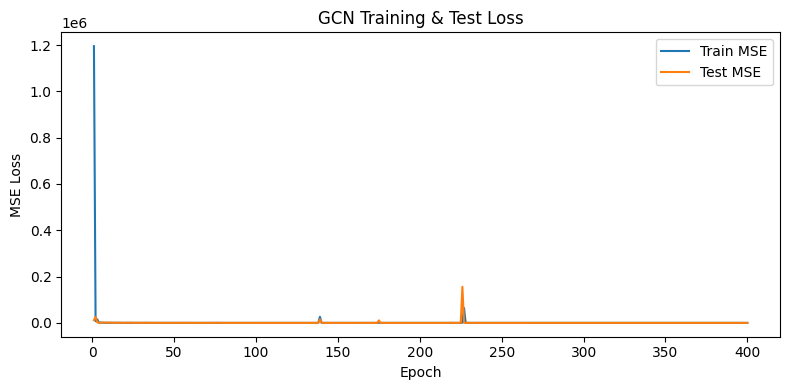

In [131]:

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train MSE")
plt.plot(epochs, test_losses,  label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GCN Training & Test Loss")
plt.legend()
plt.tight_layout()
plt.show()


Eigenvalues of learned adjacency matrix:
[ 5.21050034e+01+0.00000000e+00j  1.69136734e+01+4.42191839e+00j
  1.69136734e+01-4.42191839e+00j  7.17160225e+00+6.33458662e+00j
  7.17160225e+00-6.33458662e+00j -1.77867043e+00+7.28317595e+00j
 -1.77867043e+00-7.28317595e+00j -6.74259663e+00+3.13441324e+00j
 -6.74259663e+00-3.13441324e+00j  6.94704628e+00+0.00000000e+00j
  4.80771255e+00+4.56031752e+00j  4.80771255e+00-4.56031752e+00j
 -3.86363387e+00+5.07038546e+00j -3.86363387e+00-5.07038546e+00j
 -6.38242769e+00+0.00000000e+00j -5.92647219e+00+2.06970215e+00j
 -5.92647219e+00-2.06970215e+00j  5.96811008e+00+1.46812451e+00j
  5.96811008e+00-1.46812451e+00j  6.46755636e-01+5.78299761e+00j
  6.46755636e-01-5.78299761e+00j -1.37194121e+00+5.27863979e+00j
 -1.37194121e+00-5.27863979e+00j  5.20807457e+00+0.00000000e+00j
  4.74483824e+00+2.05164838e+00j  4.74483824e+00-2.05164838e+00j
 -3.06094074e+00+4.29940891e+00j -3.06094074e+00-4.29940891e+00j
  2.81381416e+00+4.15300417e+00j  2.81381416e+00-

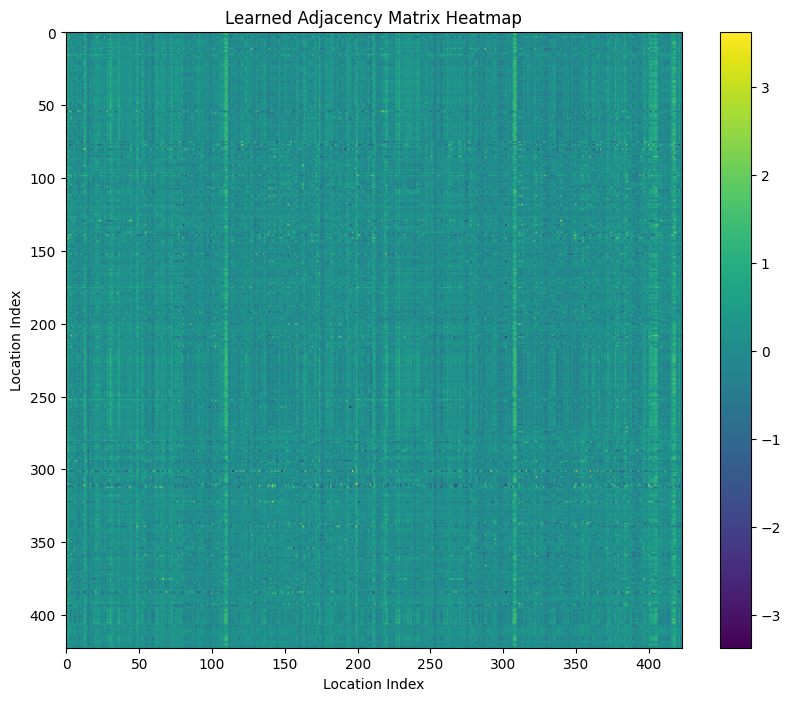

In [133]:
# find eigenvalues of the adjacency matrix of the model
with torch.no_grad():
    A_learned = model.adjacency.cpu().numpy()
eigenvalues = np.linalg.eigvals(A_learned)
print("Eigenvalues of learned adjacency matrix:")
print(eigenvalues)

# visualize the learned adjacency matrix as a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(A_learned, cmap='viridis')
plt.colorbar()
plt.title("Learned Adjacency Matrix Heatmap")
plt.xlabel("Location Index")
plt.ylabel("Location Index")
plt.show()